# Bulls Roster Optimization

Project question: how can the Chicago Bulls optimize roster construction given performance gaps, financial constraints, and market availability?

Start with `PROJECT_CONTEXT.md`, then use this notebook to build the quantitative pieces one layer at a time.

## Phase 1 Goal

Identify the Bulls' biggest measurable roster gaps, then build a first-pass player target score that can later be connected to draft and free-agency constraints.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

project_dir = Path.cwd()
if not (project_dir / "data").exists():
    project_dir = project_dir / "fresh_start"

data_dir = project_dir / "data"
bulls_df = pd.read_csv(data_dir / "bulls_roster_stats_2526.csv")
league_df = pd.read_csv(data_dir / "nba_all_players_2526.csv")

print(f"Bulls roster rows: {bulls_df.shape[0]:,}")
print(f"League player rows: {league_df.shape[0]:,}")
bulls_df.head()

Bulls roster rows: 20
League player rows: 580


,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,...,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,TEAM_COUNT
0,1641824,Matas Buzelis,Matas,1610612741,CHI,21.0,77,28,49,0.364,...,70,123,109,86,499,88,111,37,81,1
1,1630188,Jalen Smith,Jalen,1610612741,CHI,26.0,53,26,27,0.491,...,269,173,182,207,141,183,63,37,180,1
2,1630208,Nick Richards,Nick,1610612741,CHI,28.0,48,20,28,0.417,...,75,249,199,359,452,357,111,37,361,2
3,1630581,Josh Giddey,Josh,1610612741,CHI,23.0,54,21,33,0.389,...,50,291,81,75,477,21,13,2,27,1
4,1630171,Isaac Okoro,Isaac,1610612741,CHI,25.0,63,26,37,0.413,...,208,68,201,234,534,276,273,37,270,1


## Team Gap Diagnosis

This first pass compares the average Bulls player to the average non-Bulls player. It is intentionally simple: the goal is to learn the workflow before improving the basketball assumptions.

In [2]:
gap_metrics = [
    "PTS", "FG_PCT", "FG3_PCT", "FT_PCT", "AST", "TOV",
    "REB", "OREB", "DREB", "STL", "BLK", "PLUS_MINUS", "W_PCT"
]

league_non_bulls = league_df[league_df["TEAM_ABBREVIATION"] != "CHI"]

gap_rows = []
for metric in gap_metrics:
    bulls_value = bulls_df[metric].mean()
    league_value = league_non_bulls[metric].mean()
    league_std = league_non_bulls[metric].std(ddof=0)
    z_gap = (bulls_value - league_value) / league_std if league_std else 0

    gap_rows.append({
        "metric": metric,
        "bulls_avg": bulls_value,
        "league_avg": league_value,
        "raw_gap": bulls_value - league_value,
        "z_gap": z_gap,
    })

gap_df = (
    pd.DataFrame(gap_rows)
    .assign(abs_z_gap=lambda df: df["z_gap"].abs())
    .sort_values("z_gap")
    .reset_index(drop=True)
)

gap_df

,metric,bulls_avg,league_avg,raw_gap,z_gap,abs_z_gap
0,W_PCT,0.38135,0.485873,-0.104523,-0.511285,0.511285
1,FT_PCT,0.64140,0.735141,-0.093741,-0.474189,0.474189
2,STL,0.55500,0.695714,-0.140714,-0.327740,0.327740
3,PLUS_MINUS,-1.73000,-0.522500,-1.207500,-0.306324,0.306324
4,OREB,0.79500,0.952321,-0.157321,-0.189159,0.189159
5,BLK,0.33500,0.393750,-0.058750,-0.148876,0.148876
6,PTS,8.21000,9.074107,-0.864107,-0.132684,0.132684
7,REB,3.30000,3.564464,-0.264464,-0.110830,0.110830
8,FG_PCT,0.45185,0.459289,-0.007439,-0.067429,0.067429
9,DREB,2.50500,2.617321,-0.112321,-0.064441,0.064441


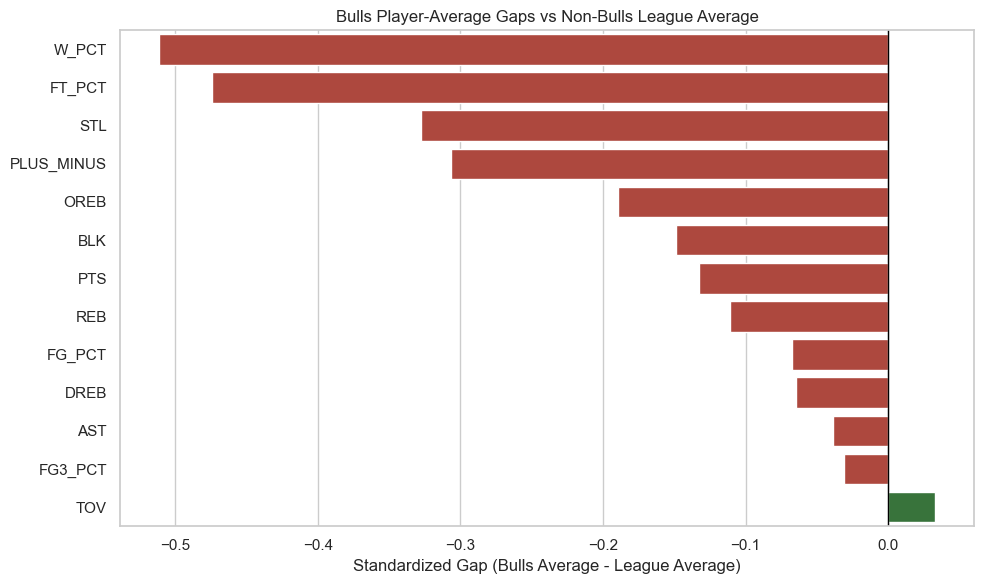

In [3]:
plt.figure(figsize=(10, 6))
chart_df = gap_df.sort_values("z_gap")
colors = ["#c0392b" if value < 0 else "#2e7d32" for value in chart_df["z_gap"]]

sns.barplot(data=chart_df, x="z_gap", y="metric", palette=colors, hue="metric", legend=False)
plt.axvline(0, color="black", linewidth=1)
plt.title("Bulls Player-Average Gaps vs Non-Bulls League Average")
plt.xlabel("Standardized Gap (Bulls Average - League Average)")
plt.ylabel("")
plt.tight_layout()

## First-Pass Target Score

A good target score should reward players who address needs without hiding the assumptions. These weights are editable. Later, we can split this into separate draft and free-agent models.

In [ ]:
score_features = {
    "BLK": 0.22,
    "DREB": 0.18,
    "REB": 0.12,
    "STL": 0.12,
    "FG3_PCT": 0.10,
    "FG3M": 0.08,
    "PTS": 0.08,
    "PLUS_MINUS": 0.06,
    "AGE": -0.04,
}

targets = league_df[league_df["TEAM_ABBREVIATION"] != "CHI"].copy()

for feature, weight in score_features.items():
    mean = targets[feature].mean()
    std = targets[feature].std(ddof=0)
    targets[f"{feature}_z"] = (targets[feature] - mean) / std if std else 0

targets["fit_score"] = sum(
    targets[f"{feature}_z"] * weight
    for feature, weight in score_features.items()
)

target_columns = [
    "PLAYER_NAME", "TEAM_ABBREVIATION", "AGE", "PTS", "REB", "DREB", "BLK", "STL",
    "FG3_PCT", "FG3M", "PLUS_MINUS", "fit_score"
]

top_targets = (
    targets.sort_values("fit_score", ascending=False)
    [target_columns]
    .head(25)
    .reset_index(drop=True)
)

top_targets

## Next Questions

Before treating this as a recommendation engine, answer these:

- Are we optimizing for a retool or rebuild?
- Which current Bulls should be treated as core players?
- Which free agents are actually available?
- What salary estimate should each target carry?
- Where is Chicago drafting, and which prospects are realistically available?